In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vaarab","key":"41c01454ad96aa96140efa089f774f2b"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
 78% 122M/157M [00:00<00:00, 1.27GB/s]
100% 157M/157M [00:00<00:00, 1.03GB/s]


In [ ]:
!unzip brain-tumor-mri-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  infl

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image size
img_size = 224
batch_size = 32

train_dir = "/content/Training"
test_dir = "/content/Testing"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical"
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4,activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 80s 414ms/step - accuracy: 0.4667 - loss: 1.1717 - val_accuracy: 0.6725 - val_loss: 1.1377
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 74s 406ms/step - accuracy: 0.7199 - loss: 0.6983 - val_accuracy: 0.7419 - val_loss: 0.8705
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 71s 403ms/step - accuracy: 0.7735 - loss: 0.5810 - val_accuracy: 0.7344 - val_loss: 1.0195
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 72s 413ms/step - accuracy: 0.7970 - loss: 0.5247 - val_accuracy: 0.7219 - val_loss: 1.1021
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 72s 410ms/step - accuracy: 0.8181 - loss: 0.4571 - val_accuracy: 0.7506 - val_loss: 0.9670
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 70s 402ms/step - accuracy: 0.8231 - loss: 0.4611 - val_accuracy: 0.7550 - val_loss: 0.9306
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 72s 409ms/step - accuracy: 0.8398 - loss: 0.4154 - val_accuracy: 0.8044 - val_loss: 0.8669
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 71s 408ms/step - accuracy: 0.8402 - loss: 0

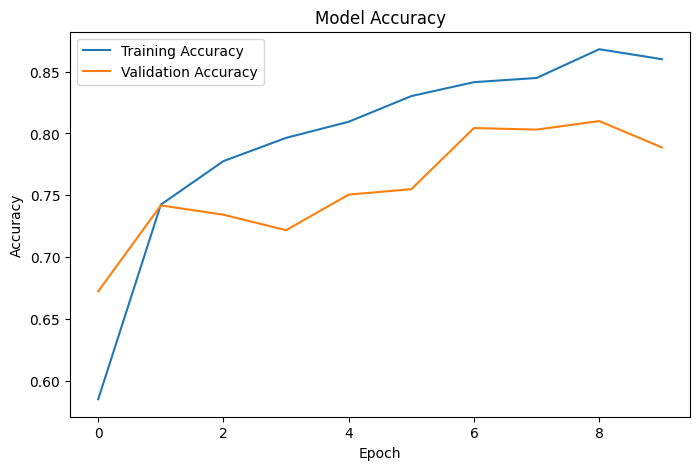

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training Accuracy','Validation Accuracy'])

plt.show()

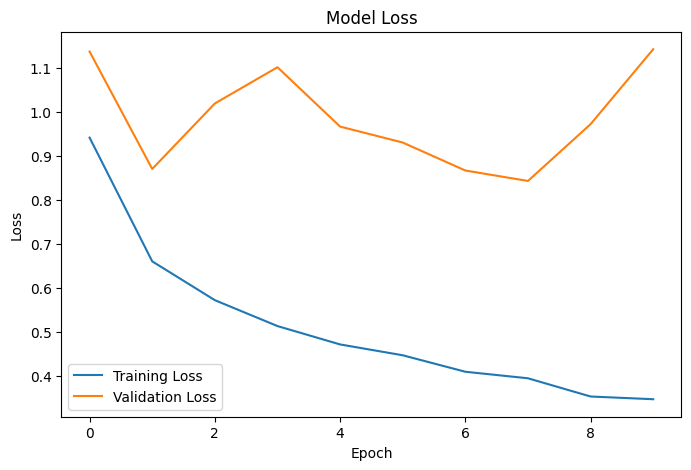

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training Loss','Validation Loss'])

plt.show()

In [ ]:
import os
os.listdir('/content')

['.config',
 'kaggle.json',
 'brain-tumor-mri-dataset.zip',
 'Training',
 'Testing',
 'sample_data']

In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
brain-tumor-mri-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"vaarab","key":"41c01454ad96aa96140efa089f774f2b"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
brain-tumor-mri-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip brain-tumor-mri-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  infl

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"vaarab","key":"41c01454ad96aa96140efa089f774f2b"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
brain-tumor-mri-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip brain-tumor-mri-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  infl

In [ ]:
import os
os.listdir('/content')

['.config',
 'kaggle (2).json',
 'kaggle.json',
 'brain-tumor-mri-dataset.zip',
 'Training',
 'Testing',
 'kaggle (1).json',
 'sample_data']

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    '/content/Testing',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

Found 1600 images belonging to 4 classes.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 807ms/step
Predicted Tumor Type: notumor


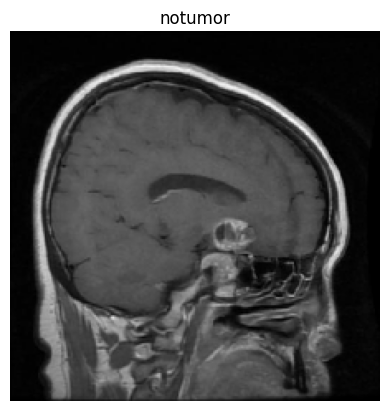

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# get one batch from test dataset
images, labels = next(test_data)

# select first image
img = images[0]

# predict
prediction = model.predict(np.expand_dims(img, axis=0))

classes = ['glioma','meningioma','pituitary','notumor']
predicted_class = classes[np.argmax(prediction)]

print("Predicted Tumor Type:", predicted_class)

# show MRI image
plt.imshow(img)
plt.title(predicted_class)
plt.axis("off")
plt.show()

In [ ]:
model.save("brain_tumor_model.h5")